In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('ToyotaCorolla.csv')

In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.shape

(1436, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [8]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

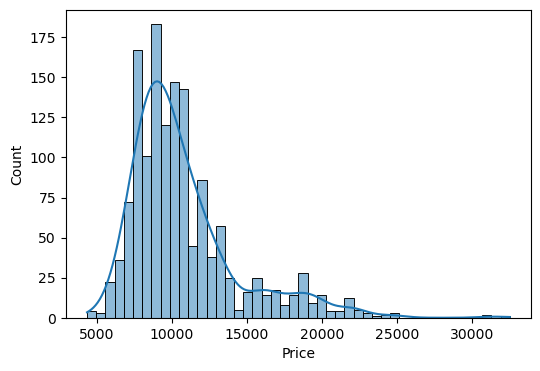

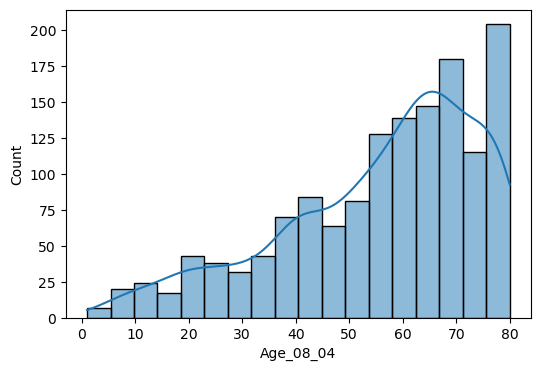

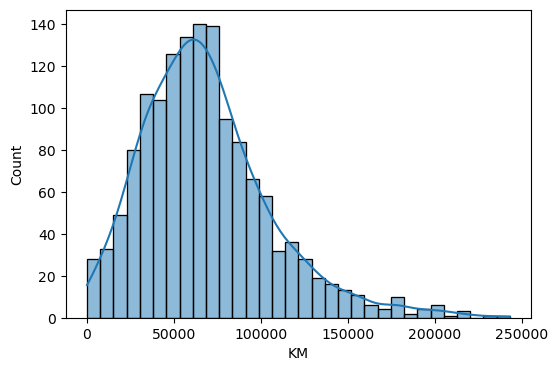

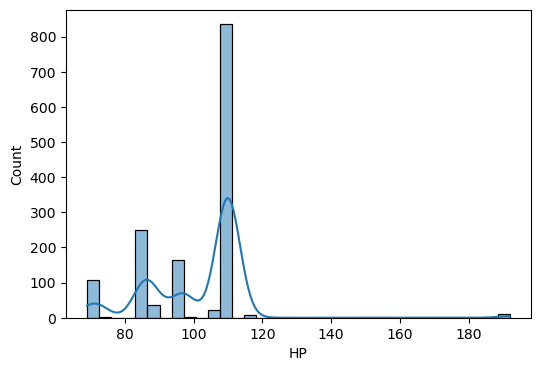

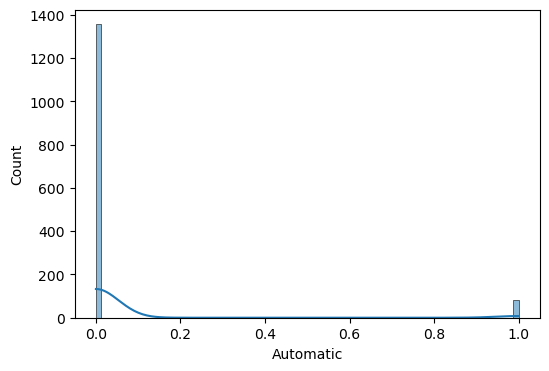

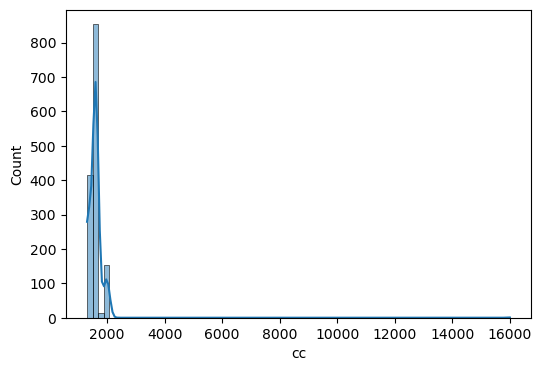

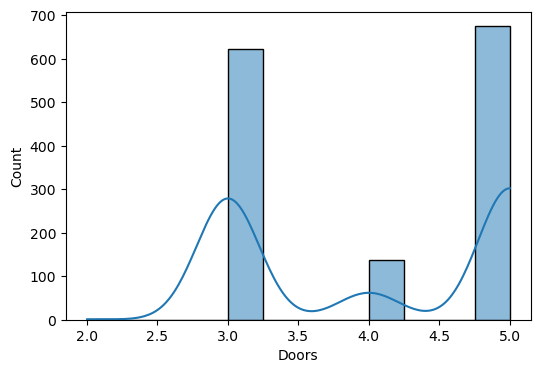

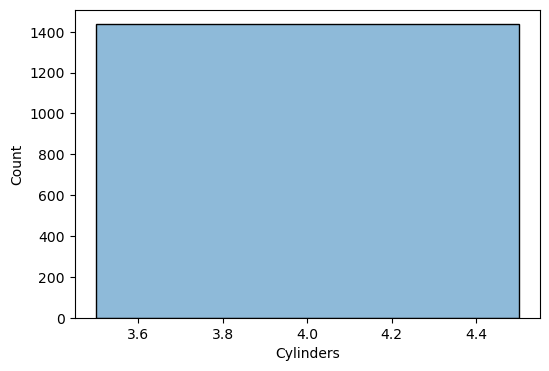

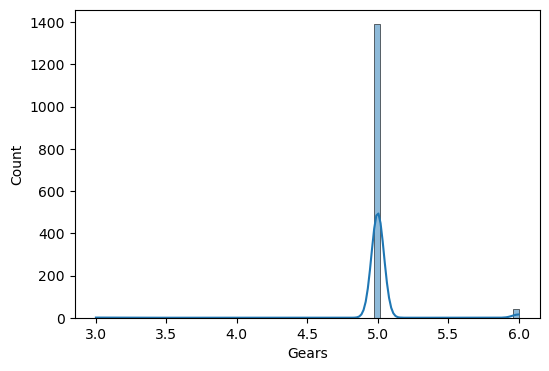

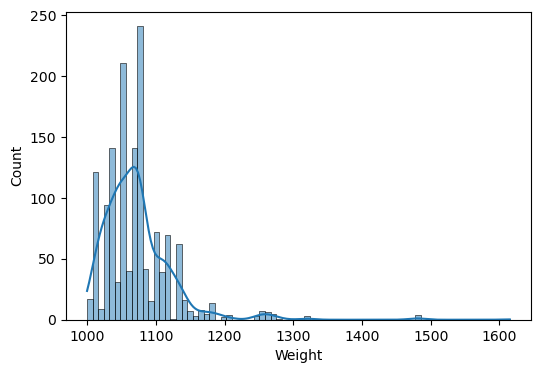

In [9]:
numeric =['Price', 'Age_08_04', 'KM',  'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight']
for i in numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True,)

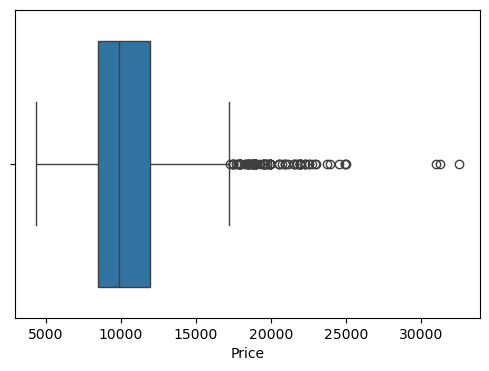

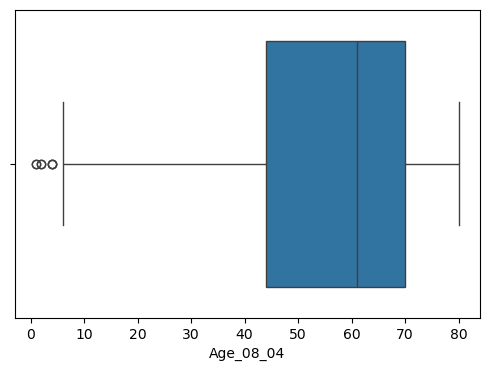

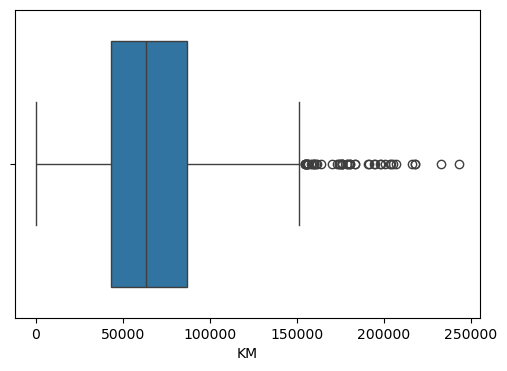

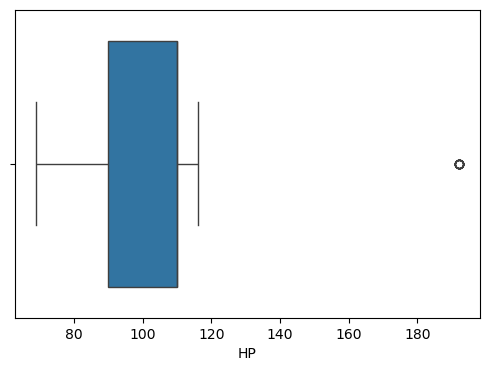

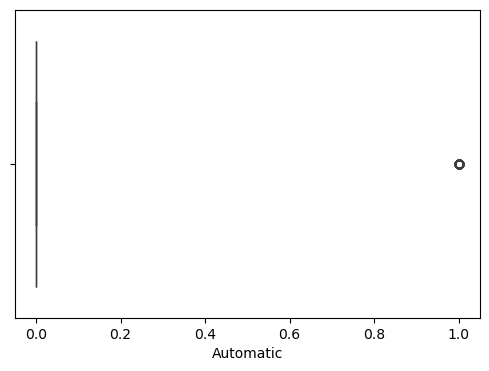

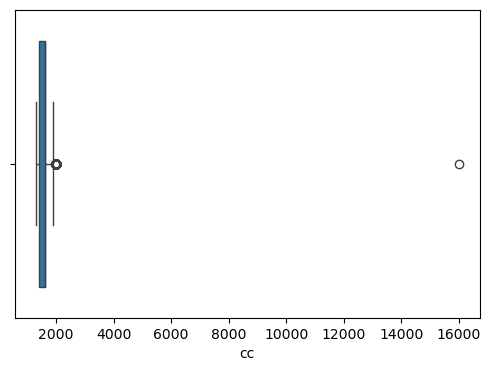

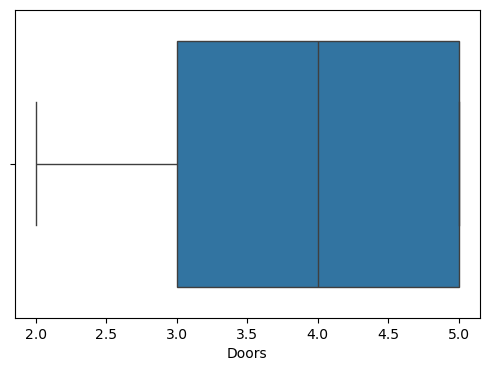

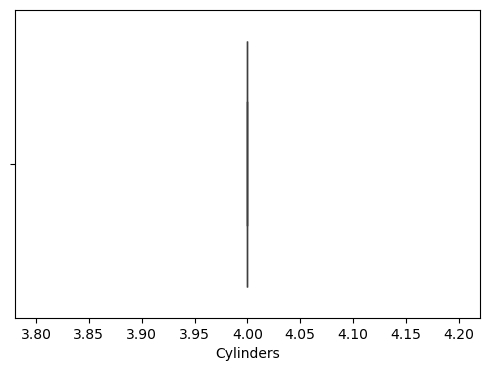

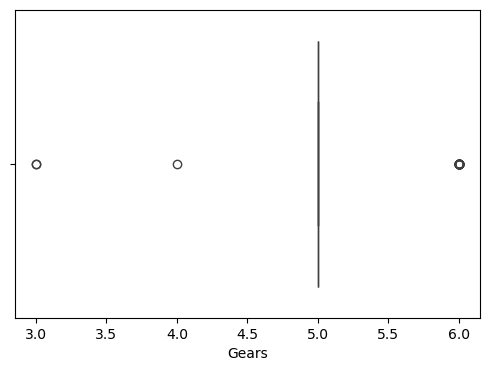

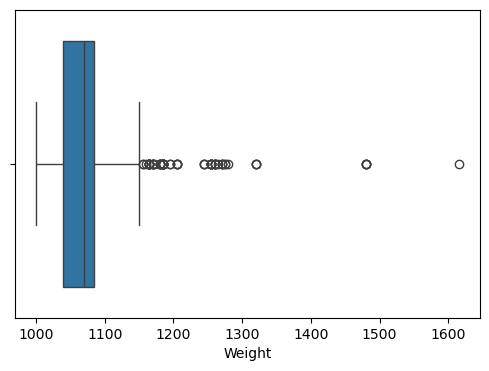

In [10]:
for i in numeric:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[i])

<Axes: >

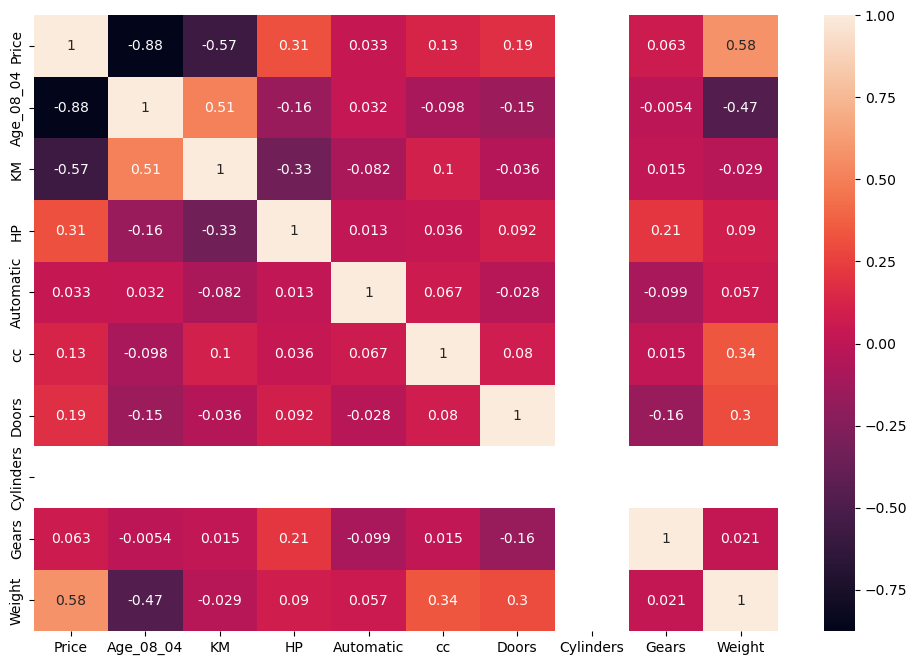

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only = True),annot=True)

In [6]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [7]:
df['Fuel_Type']=df['Fuel_Type'].map({"Petrol" : 0, "Diesel" : 1 , "CNG": 2})

In [8]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170


In [9]:
df.drop_duplicates(inplace = True)

In [10]:
df.shape

(1435, 11)

In [11]:
X = df.drop(['Price'],axis=1)

In [14]:
Y = df['Price']

In [15]:
Y.head()

0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64

In [16]:
X.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23,46986,1,90,0,2000,3,4,5,1165
1,23,72937,1,90,0,2000,3,4,5,1165
2,24,41711,1,90,0,2000,3,4,5,1165
3,26,48000,1,90,0,2000,3,4,5,1165
4,30,38500,1,90,0,2000,3,4,5,1170


In [21]:
X_train,x_test,Y_train,y_test=train_test_split(X,Y, test_size=0.2, random_state=42)

In [22]:
df.corr()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876273,-0.569420,0.015883,0.314134,0.033928,0.124375,0.183604,NaN,0.063831,0.575869
Age_08_04,-0.876273,1.000000,0.504575,-0.076382,-0.155293,0.031354,-0.096549,-0.146929,NaN,-0.005629,-0.466484
KM,-0.569420,0.504575,1.000000,0.424118,-0.332904,-0.082168,0.103822,-0.035193,NaN,0.014890,-0.023969
Fuel_Type,0.015883,-0.076382,0.424118,1.000000,-0.411973,-0.069456,0.276236,0.025339,NaN,-0.069560,0.502479
HP,0.314134,-0.155293,-0.332904,-0.411973,1.000000,0.013313,0.035207,0.091803,NaN,0.209642,0.087143
Automatic,0.033928,0.031354,-0.082168,-0.069456,0.013313,1.000000,0.066934,-0.027492,NaN,-0.098582,0.058499
cc,0.124375,-0.096549,0.103822,0.276236,0.035207,0.066934,1.000000,0.079254,NaN,0.014732,0.335077
Doors,0.183604,-0.146929,-0.035193,0.025339,0.091803,-0.027492,0.079254,1.000000,NaN,-0.160101,0.301734
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063831,-0.005629,0.014890,-0.069560,0.209642,-0.098582,0.014732,-0.160101,NaN,1.000000,0.021238


In [23]:
from sklearn.metrics import r2_score,root_mean_squared_error

In [24]:
#Task 1 : Create Model 1: using all the features
model1 = LinearRegression()

#Training The Dataa
model1.fit(X_train,Y_train)
#Testing and predicting the data
Y_Pred_Model1 = model1.predict(x_test)
r2_score_model1 = r2_score(y_test,Y_Pred_Model1)
rmse_model1 = root_mean_squared_error(y_test,Y_Pred_Model1)
print(f'Model1:R2 Score {round(r2_score_model1,2)}, RMSE : {round(rmse_model1,2)}')


Model1:R2 Score 0.83, RMSE : 1416.53


In [27]:
print(X_train.columns)

Index(['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')


In [26]:
#Task 2 : Create Model 1: Using all the features expect the Automatic
model2 = LinearRegression()

#Training The Dataa
model2.fit(X_train,Y_train)
#Testing and predicting the data
Y_Pred_Model2 = model2.predict(x_test)
r2_score_model2 = r2_score(y_test,Y_Pred_Model2)
rmse_model2 = root_mean_squared_error(y_test,Y_Pred_Model2)
print(f'Model2:R2 Score {round(r2_score_model2,2)}, RMSE : {round(rmse_model2,2)}')


Model2:R2 Score 0.83, RMSE : 1416.53


In [29]:
X=df[['Age_08_04', 'KM','HP','Weight']]

In [30]:
X.head()

,Age_08_04,KM,HP,Weight
0,23,46986,90,1165
1,23,72937,90,1165
2,24,41711,90,1165
3,26,48000,90,1165
4,30,38500,90,1170


In [31]:
Y=df['Price']

In [32]:
Y.head()

0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64

In [33]:
x_train,x_test1,y_train,y_test1=train_test_split(X,Y,test_size=0.2,random_state=42)

In [34]:
#Task 3 : Create Model 1: Using only the important featuress
model3 = LinearRegression()

#Training The Dataa
model3.fit(x_train,y_train)
#Testing and predicting the data
Y_Pred_Model3 = model3.predict(x_test1)
r2_score_model3 = r2_score(y_test1,Y_Pred_Model3)
rmse_model3 = root_mean_squared_error(y_test1,Y_Pred_Model3)
print(f'Model2:R2 Score {round(r2_score_model3,2)}, RMSE : {round(rmse_model3,2)}')


Model2:R2 Score 0.84, RMSE : 1390.86


In [ ]:
## reading the dataset into new dr so that all the variable will be present 

In [35]:
dr=pd.read_csv('ToyotaCorolla.csv')

In [36]:
dr.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [39]:
dr.drop_duplicates()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [38]:
dr.shape

(1436, 11)

In [40]:
dr['Fuel_Type']=dr['Fuel_Type'].map({'Diesel':0,'Petrol':1,'CNG':2})

In [41]:
dr.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,0,90,0,2000,3,4,5,1165
1,13750,23,72937,0,90,0,2000,3,4,5,1165
2,13950,24,41711,0,90,0,2000,3,4,5,1165
3,14950,26,48000,0,90,0,2000,3,4,5,1165
4,13750,30,38500,0,90,0,2000,3,4,5,1170


In [46]:
X=dr.drop(['Price'],axis=1)

In [47]:
Y=dr['Price']

In [48]:
X.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23,46986,0,90,0,2000,3,4,5,1165
1,23,72937,0,90,0,2000,3,4,5,1165
2,24,41711,0,90,0,2000,3,4,5,1165
3,26,48000,0,90,0,2000,3,4,5,1165
4,30,38500,0,90,0,2000,3,4,5,1170


In [49]:
Y.head()

0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64

In [50]:
X_train,x_test,Y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [55]:
## linear regression with all the features
model=LinearRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(x_test)
r2_score_moddel=r2_score(y_test,y_pred)
rmse_model = root_mean_squared_error(y_test,y_pred)
print(f'Model2:R2 Score {round(r2_score_moddel,2)}, RMSE : {round(rmse_model,2)}')

Model2:R2 Score 0.85, RMSE : 1415.53


In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(x_test)

In [66]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, Y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

In [67]:

print("R² :", r2_score(y_test, y_pred_ridge))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R² : 0.8498359738397886
RMSE : 1415.4882171801398


In [60]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, Y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

In [61]:
print("R² :", r2_score(y_test, y_pred_lasso))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

R² : 0.8499135058348319
RMSE : 1415.122750837296


In [ ]:
## normalization is X-Xmin/Xmax-Xmin , but this is effected by the outlier 
## standardization is nothing but the z-score this is also effected by the outlier,  both help in bringing the valuees of the ccolumns into the same value, 